## Tasks

### Task 1: Build and Summarize Synthetic Datasets

Start by creating three synthetic datasets that represent different distribution shapes. Each dataset should have **500** observations.

1. **Dataset A** — Symmetric: draw from a normal distribution with mean = 50 and standard deviation = 10.
2. **Dataset B** — Right-skewed: draw from an exponential distribution, then shift and scale so the values fall roughly in the 0–100 range.
3. **Dataset C** — Bimodal: combine two normal distributions (e.g., means at 30 and 70) with equal sample sizes.

For each dataset, compute and display in a summary table:
- Mean, median, mode (rounded to 2 decimals)
- Standard deviation, variance, IQR
- Skewness and kurtosis (use `scipy.stats.skew` and `scipy.stats.kurtosis`)

**Guiding question:** Which summary statistics look similar across the three datasets, and which reveal the differences?

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis, mode

np.random.seed(42)

dataset_a = pd.Series(np.random.normal(50, 10, 500))

dataset_b = np.random.exponential(scale=1, size=500)
dataset_b = dataset_b / dataset_b.max() * 100
dataset_b = pd.Series(dataset_b)

dataset_c_1 = np.random.normal(30, 10, 250)
dataset_c_2 = np.random.normal(70, 10, 250)
dataset_c = pd.Series(np.concatenate([dataset_c_1, dataset_c_2]))

def summarize(data):
    mean = round(data.mean(), 2)
    median = round(data.median(), 2)
    mode_val = round(mode(data, keepdims=True).mode[0], 2)
    std = round(data.std(), 2)
    var = round(data.var(), 2)
    iqr = round(data.quantile(0.75) - data.quantile(0.25), 2)
    skewness = round(skew(data), 2)
    kurt = round(kurtosis(data), 2)

    return [mean, median, mode_val, std, var, iqr, skewness, kurt]

summary = pd.DataFrame(
    [summarize(dataset_a), summarize(dataset_b), summarize(dataset_c)],
    columns=["Mean", "Median", "Mode", "Std", "Variance", "IQR", "Skewness", "Kurtosis"],
    index=["Dataset A", "Dataset B", "Dataset C"]
)

print(summary)

            Mean  Median   Mode    Std  Variance    IQR  Skewness  Kurtosis
Dataset A  50.07   50.13  17.59   9.81     96.29  13.37      0.18      0.26
Dataset B  16.23   11.35   0.08  15.98    255.26  18.64      1.77      3.98
Dataset C  50.65   50.15   1.04  21.75    473.01  38.03      0.03     -1.18


### Task 1 Analysis

Dataset A is symmetric, so its mean and median are very close, reflecting the balance of the data. Dataset B is right-skewed, with the mean pulled higher than the median by a few large values, creating a long tail. Dataset C is bimodal, and while the mean and median are close, the data clusters around two peaks, which increases spread.

Overall, standard deviation, IQR, skewness, and kurtosis reveal the differences between the datasets more clearly than mean and median alone, highlighting symmetry, skewness, and multimodality.

### Task 2: Visualize the Distributions

Create a figure with **three rows and three columns** (9 subplots total). Each row represents one dataset (A, B, C). The columns are:

1. **Histogram** with 30 bins and a KDE overlay.
2. **Boxplot** (horizontal orientation).
3. **KDE plot** alone, with vertical lines marking the mean (dashed red) and median (solid blue).

Add clear titles and axis labels to every subplot. Use `plt.tight_layout()` to prevent overlap.

**Guiding question:** For which dataset(s) do the mean and median diverge the most? What visual feature explains the divergence?

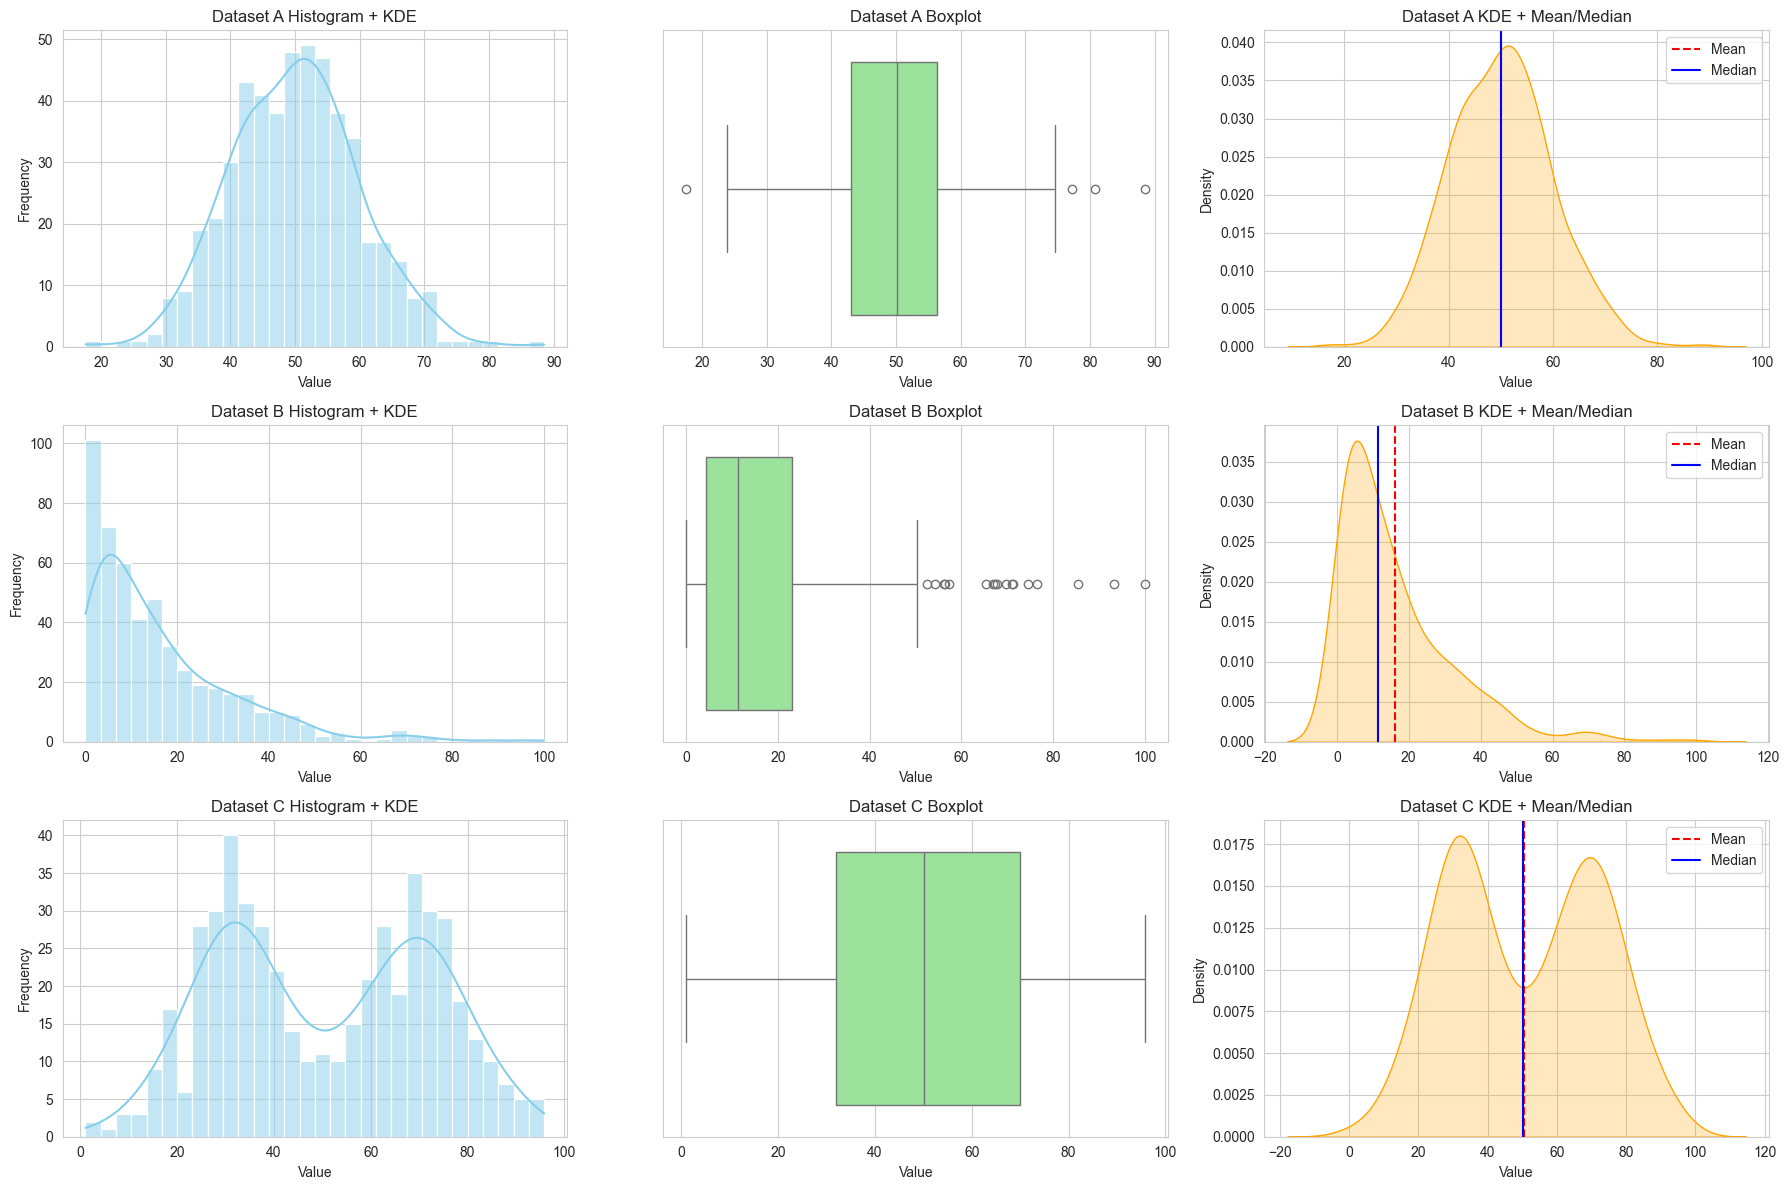

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

datasets = [dataset_a, dataset_b, dataset_c]
dataset_names = ['Dataset A', 'Dataset B', 'Dataset C']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for i, data in enumerate(datasets):
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{dataset_names[i]} Histogram + KDE')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Frequency')

    sns.boxplot(x=data, ax=axes[i, 1], color='lightgreen', orient='h')
    axes[i, 1].set_title(f'{dataset_names[i]} Boxplot')
    axes[i, 1].set_xlabel('Value')

    sns.kdeplot(data, fill=True, ax=axes[i, 2], color='orange')
    mean_val = data.mean()
    median_val = data.median()
    axes[i, 2].axvline(mean_val, color='red', linestyle='--', label='Mean')
    axes[i, 2].axvline(median_val, color='blue', linestyle='-', label='Median')
    axes[i, 2].set_title(f'{dataset_names[i]} KDE + Mean/Median')
    axes[i, 2].set_xlabel('Value')
    axes[i, 2].set_ylabel('Density')
    axes[i, 2].legend()

plt.tight_layout()
plt.show()

### Task 2 Analysis

The dataset where the mean and median diverge the most is Dataset B.

Looking at the visualizations, we can see why this happens: Dataset B is right-skewed, meaning most of the data is concentrated on the lower end, but there are a few large values stretching far to the right. This long tail pulls the mean to the right, while the median remains closer to the center of the bulk of the data.

In the KDE plot with mean and median lines, this divergence is clearly visible: the red dashed line (mean) is shifted to the right of the blue solid line (median). The histogram + KDE plot also shows the asymmetric shape with the extended tail, confirming the skewness.

In contrast, Dataset A is nearly symmetric, and Dataset C, although bimodal, has mean and median relatively close, so the divergence is much less noticeable in those datasets.

In short: The large difference between mean and median in Dataset B is caused by its right-skewed distribution with a long tail, which is clearly reflected in the visual plots.

### Task 3: The Outlier Stress Test

Take **Dataset A** (the symmetric one) and create a modified copy:

1. Replace the **5 largest values** with extreme outliers: multiply each by 10.
2. Compute the same summary statistics table as Task 1 for both the original and modified versions.
3. Create side-by-side boxplots (original vs. modified) and overlay the mean as a diamond marker on each.

Answer the following in a markdown cell:
- Which statistics changed the most? Which were robust?
- If you were reporting a "typical" value for the modified dataset, would you choose the mean or the median? Why?

                     Mean  Median   Mode    Std  Variance    IQR  Skewness  \
Original Dataset A  50.07   50.13  17.59   9.81     96.29  13.37      0.18   
Modified Dataset A  57.17   50.13  17.59  74.38   5532.48  13.37      9.70   

                    Kurtosis  
Original Dataset A      0.26  
Modified Dataset A     94.18  


C:\Users\user\AppData\Local\Temp\ipykernel_21048\707089761.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dataset', y='Value', data=df_box, palette=['skyblue', 'lightcoral'])


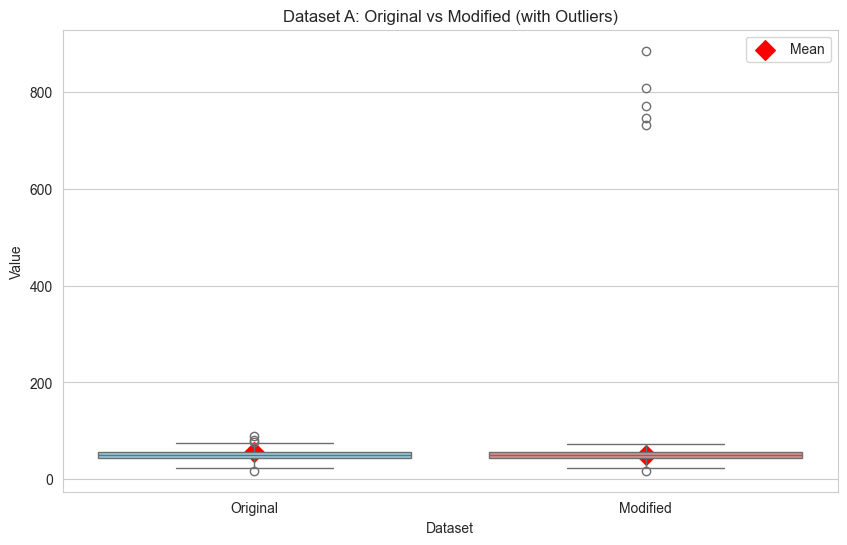

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import skew, kurtosis, mode

dataset_a_outlier = dataset_a.copy()
top5_idx = dataset_a_outlier.nlargest(5).index
dataset_a_outlier.loc[top5_idx] *= 10

def summarize(data):
    mean = round(data.mean(), 2)
    median = round(data.median(), 2)
    mode_val = round(mode(data, keepdims=True).mode[0], 2)
    std = round(data.std(), 2)
    var = round(data.var(), 2)
    iqr = round(data.quantile(0.75) - data.quantile(0.25), 2)
    skewness = round(skew(data), 2)
    kurt = round(kurtosis(data), 2)
    return [mean, median, mode_val, std, var, iqr, skewness, kurt]

summary_outlier = pd.DataFrame(
    [summarize(dataset_a), summarize(dataset_a_outlier)],
    columns=["Mean", "Median", "Mode", "Std", "Variance", "IQR", "Skewness", "Kurtosis"],
    index=["Original Dataset A", "Modified Dataset A"]
)
print(summary_outlier)

df_box = pd.DataFrame({
    'Value': pd.concat([dataset_a, dataset_a_outlier]),
    'Dataset': ['Original']*len(dataset_a) + ['Modified']*len(dataset_a_outlier)
})

plt.figure(figsize=(10,6))
sns.boxplot(x='Dataset', y='Value', data=df_box, palette=['skyblue', 'lightcoral'])
means = df_box.groupby('Dataset')['Value'].mean()
plt.scatter([0,1], means.values, color='red', marker='D', s=100, label='Mean')
plt.ylabel('Value')
plt.title('Dataset A: Original vs Modified (with Outliers)')
plt.legend()
plt.show()

### Task 3 Analysis

The statistics that changed the most after adding the extreme outliers were mean, standard deviation, variance, skewness, and kurtosis. These measures are highly sensitive to extreme values. On the other hand, median, mode, and IQR remained largely unchanged, showing that they are more robust to outliers.

If we were reporting a "typical" value for the modified dataset, it would be more appropriate to choose the median rather than the mean. The mean is heavily influenced by the extreme outliers and no longer represents the central tendency of the bulk of the data, whereas the median continues to reflect the typical value accurately.